In [1]:
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from collections import Counter

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100

from datetime import date
today = str(date.today())

In [2]:
import dandelion as ddl

/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/lib/python3.14/site-packages/nxviz/__init__.py:33: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)



In [3]:
ddl.logging.print_versions()

dandelion==0.5.7 pandas==2.3.3 numpy==2.4.5 matplotlib==3.10.9 networkx==3.6.1 scipy==1.17.1


In [4]:
import scanpy as sc

In [5]:
import scirpy as ir

/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [6]:
import os, shutil, sys

print(sys.executable)
print(os.environ.get("R_HOME"))
print(shutil.which("R"))
print(os.environ["PATH"])

/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/bin/python
/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/lib/R
/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/bin/R
/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin


In [7]:
import rpy2.robjects as ro

print(ro.r("R.version.string")[0])
print(ro.r("R.home()")[0])
print(ro.r(".libPaths()"))

R version 4.5.3 (2026-03-11)
/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/lib/R
[1] "/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/lib/R/library"



In [8]:
import rpy2.rinterface_lib.callbacks
%load_ext rpy2.ipython

## BCR Reannotation 

In [9]:
personal_folder = 'anamaceiras' # <- add you folder name

In [12]:
# change directory to folder with metadata
os.chdir(os.path.expanduser('/mnt/nfs/home/'+personal_folder+'/BCR_TCR/TCR_BCR_data'))
# print current working directory
os.getcwd()

'/mnt/nfs/home/anamaceiras/BCR_TCR/TCR_BCR_data'

### Samples list

In [13]:
metadata = pd.read_csv('samples_list.csv', index_col=0)

In [11]:
metadata = metadata[metadata.donor_list=='694B'] #either 694B, 759B, or 778C

In [12]:
metadata.head(2)

,sample_library_id,donor_list
0,694B_001_BCR_CZI-IA11485873,694B
2,694B_001_BCR_CZI-IA11512685,694B


In [13]:
samples = metadata['sample_library_id']
len(samples)

14

In [14]:
donor_list = list(set(metadata.donor_list))
donor_list.sort()
donor_list

['694B']

In [15]:
#TCR_samples=[]
BCR_samples=[]
for s in samples:
    if 'BCR' in s:
        BCR_samples.append(s)
#print(TCR_samples)
print(BCR_samples)

['694B_001_BCR_CZI-IA11485873', '694B_001_BCR_CZI-IA11512685', '694B_001_BCR_CZI-IA11512686', '694B_001_BCR_CZI-IA11512687', '694B_001_BCR_CZI-IA11512688', '694B_001_BCR_CZI-IA11512689', '694B_001_BCR_CZI-IA11512690']


In [16]:
len(BCR_samples)

7

In [17]:
BCR_samples.sort()
BCR_samples[:5]

['694B_001_BCR_CZI-IA11485873',
 '694B_001_BCR_CZI-IA11512685',
 '694B_001_BCR_CZI-IA11512686',
 '694B_001_BCR_CZI-IA11512687',
 '694B_001_BCR_CZI-IA11512688']

In [18]:
donor_dic_BCR = {}
int_list = []
for donor in donor_list:
    for s in BCR_samples:
        if donor in s:
            #print(s)
            int_list.append(s)
    donor_dic_BCR[donor] = int_list
    
    #print(donor_list)
    int_list = []
donor_dic_BCR

{'694B': ['694B_001_BCR_CZI-IA11485873',
  '694B_001_BCR_CZI-IA11512685',
  '694B_001_BCR_CZI-IA11512686',
  '694B_001_BCR_CZI-IA11512687',
  '694B_001_BCR_CZI-IA11512688',
  '694B_001_BCR_CZI-IA11512689',
  '694B_001_BCR_CZI-IA11512690']}

In [19]:
BCRsamples_prefix=[x.split('_')[3] for x in BCR_samples]
BCRsamples_prefix[:5]

['CZI-IA11485873',
 'CZI-IA11512685',
 'CZI-IA11512686',
 'CZI-IA11512687',
 'CZI-IA11512688']

### Change working directory

### Step 1: Formatting the headers of the Cell Ranger fasta file

In [21]:
# the first option is a list of fasta files to format and the second option is the list of prefix to add to each file.
ddl.pp.format_fastas(BCR_samples, filename_prefix = [x+'.cellranger.all' for x in BCR_samples], suffix=BCRsamples_prefix)

Formatting fasta(s) : 100%|██████████| 7/7 [00:04<00:00,  1.66it/s]


### Step 2: Reannotate the V/D/J genes with igblastn

In [22]:
ddl.pp.reannotate_genes(BCR_samples, filename_prefix = [x+'.cellranger.all' for x in BCR_samples])

Assigning genes :   0%|          | 0/7 [00:00<?, ?it/s]

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> 694B_001_BCR_CZI-IA11485873.cellranger.all_contig_igblast.fmt7
      SEQ_FILE> 694B_001_BCR_CZI-IA11485873.cellranger.all_contig.fasta
         NPROC> 64
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 09:29:18 |Done                | 0.0 min

PROGRESS> 09:29:32 |####################| 100% (35,660) 0.2 min

OUTPUT> 694B_001_BCR_CZI-IA11485873.cellranger.all_contig_igblast_db-pass.tsv
  PASS> 33939
  FAIL> 1721
   END> MakeDb

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> 694B_001_BCR_CZI-IA11485873.cellranger.all_contig_igblast.fmt7
      SEQ_FILE> 694B_001_BCR_CZI-IA11485873.cellranger.all_contig.fasta
         NPROC> 64
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 09:29:33 |Done                | 0.0 min

PROGRESS> 09:29:47 |####################| 100% (35,660) 

Assigning genes :  14%|█▍        | 1/7 [08:12<49:14, 492.40s/it]

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> 694B_001_BCR_CZI-IA11512685.cellranger.all_contig_igblast.fmt7
      SEQ_FILE> 694B_001_BCR_CZI-IA11512685.cellranger.all_contig.fasta
         NPROC> 64
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 09:34:22 |Done                | 0.0 min

PROGRESS> 09:34:30 |####################| 100% (19,248) 0.1 min

OUTPUT> 694B_001_BCR_CZI-IA11512685.cellranger.all_contig_igblast_db-pass.tsv
  PASS> 18947
  FAIL> 301
   END> MakeDb

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> 694B_001_BCR_CZI-IA11512685.cellranger.all_contig_igblast.fmt7
      SEQ_FILE> 694B_001_BCR_CZI-IA11512685.cellranger.all_contig.fasta
         NPROC> 64
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 09:34:31 |Done                | 0.0 min

PROGRESS> 09:34:38 |####################| 100% (19,248) 0

Assigning genes :  29%|██▊       | 2/7 [12:35<29:46, 357.34s/it]

...

Assigning genes :  71%|███████▏  | 5/7 [35:56<15:51, 475.66s/it]

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> 694B_001_BCR_CZI-IA11512689.cellranger.all_contig_igblast.fmt7
      SEQ_FILE> 694B_001_BCR_CZI-IA11512689.cellranger.all_contig.fasta
         NPROC> 64
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 10:04:12 |Done                | 0.0 min

PROGRESS> 10:04:23 |####################| 100% (28,794) 0.2 min

OUTPUT> 694B_001_BCR_CZI-IA11512689.cellranger.all_contig_igblast_db-pass.tsv
  PASS> 27846
  FAIL> 948
   END> MakeDb

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> 694B_001_BCR_CZI-IA11512689.cellranger.all_contig_igblast.fmt7
      SEQ_FILE> 694B_001_BCR_CZI-IA11512689.cellranger.all_contig.fasta
         NPROC> 64
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 10:04:24 |Done                | 0.0 min

PROGRESS> 10:04:35 |####################| 100% (28,794) 0

Assigning genes :  86%|████████▌ | 6/7 [42:50<07:34, 454.56s/it]

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> 694B_001_BCR_CZI-IA11512690.cellranger.all_contig_igblast.fmt7
      SEQ_FILE> 694B_001_BCR_CZI-IA11512690.cellranger.all_contig.fasta
         NPROC> 64
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 10:06:29 |Done                | 0.0 min

PROGRESS> 10:06:31 |####################| 100% (6,056) 0.0 min

OUTPUT> 694B_001_BCR_CZI-IA11512690.cellranger.all_contig_igblast_db-pass.tsv
  PASS> 5961
  FAIL> 95
   END> MakeDb

         START> MakeDB
       COMMAND> igblast
  ALIGNER_FILE> 694B_001_BCR_CZI-IA11512690.cellranger.all_contig_igblast.fmt7
      SEQ_FILE> 694B_001_BCR_CZI-IA11512690.cellranger.all_contig.fasta
         NPROC> 64
       ASIS_ID> False
    ASIS_CALLS> False
      VALIDATE> strict
      EXTENDED> True
INFER_JUNCTION> False

PROGRESS> 10:06:32 |Done                | 0.0 min

PROGRESS> 10:06:35 |####################| 100% (6,056) 0.0 m

Assigning genes : 100%|██████████| 7/7 [44:09<00:00, 378.54s/it]


### Step 3 : Reassigning heavy chain V gene alleles (optional but recommended)

694B 
 ['694B_001_BCR_CZI-IA11485873', '694B_001_BCR_CZI-IA11512685', '694B_001_BCR_CZI-IA11512686', '694B_001_BCR_CZI-IA11512687', '694B_001_BCR_CZI-IA11512688', '694B_001_BCR_CZI-IA11512689', '694B_001_BCR_CZI-IA11512690']


Processing data file(s) :   0%|          | 0/7 [00:00<?, ?it/s]

  START> ParseDb
COMMAND> select
   FILE> 694B_001_BCR_CZI-IA11485873.cellranger.all_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IGH
  REGEX> True

PROGRESS> 10:24:03 |####################| 100% (33,939) 0.0 min

   OUTPUT> 694B_001_BCR_CZI-IA11485873.cellranger.all_contig_igblast_db-pass_heavy_parse-select.tsv
  RECORDS> 33939
 SELECTED> 8387
DISCARDED> 25552
      END> ParseDb

  START> ParseDb
COMMAND> select
   FILE> 694B_001_BCR_CZI-IA11485873.cellranger.all_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IG[LK]
  REGEX> True

PROGRESS> 10:24:05 |################### |  95% (32,243) 0.0 min

Processing data file(s) :  14%|█▍        | 1/7 [00:03<00:19,  3.17s/it]

PROGRESS> 10:24:05 |####################| 100% (33,939) 0.0 min

   OUTPUT> 694B_001_BCR_CZI-IA11485873.cellranger.all_contig_igblast_db-pass_light_parse-select.tsv
  RECORDS> 33939
 SELECTED> 25552
DISCARDED> 8387
      END> ParseDb

  START> ParseDb
COMMAND> select
   FILE> 694B_001_BCR_CZI-IA11512685.cellranger.all_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IGH
  REGEX> True

PROGRESS> 10:24:06 |####################| 100% (18,947) 0.0 min

   OUTPUT> 694B_001_BCR_CZI-IA11512685.cellranger.all_contig_igblast_db-pass_heavy_parse-select.tsv
  RECORDS> 18947
 SELECTED> 5550
DISCARDED> 13397
      END> ParseDb

  START> ParseDb
COMMAND> select
   FILE> 694B_001_BCR_CZI-IA11512685.cellranger.all_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IG[LK]
  REGEX> True

PROGRESS> 10:24:07 |####################| 100% (18,947) 0.0 min

   OUTPUT> 694B_001_BCR_CZI-IA11512685.cellranger.all_contig_igblast_db-pass_light_parse-select.tsv
  RECORDS> 18947
 SELECTED> 13397
DISCARDED> 5550
  

...

PROGRESS> 10:24:16 |####################| 100% (39,770) 0.0 min

   OUTPUT> 694B_001_BCR_CZI-IA11512688.cellranger.all_contig_igblast_db-pass_light_parse-select.tsv
  RECORDS> 39770
 SELECTED> 27649
DISCARDED> 12121
      END> ParseDb

  START> ParseDb
COMMAND> select
   FILE> 694B_001_BCR_CZI-IA11512689.cellranger.all_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IGH
  REGEX> True

PROGRESS> 10:24:17 |####################| 100% (27,846) 0.0 min

   OUTPUT> 694B_001_BCR_CZI-IA11512689.cellranger.all_contig_igblast_db-pass_heavy_parse-select.tsv
  RECORDS> 27846
 SELECTED> 9510
DISCARDED> 18336
      END> ParseDb

  START> ParseDb
COMMAND> select
   FILE> 694B_001_BCR_CZI-IA11512689.cellranger.all_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IG[LK]
  REGEX> True

PROGRESS> 10:24:19 |################### |  95% (26,467) 0.0 min

Processing data file(s) :  86%|████████▌ | 6/7 [00:16<00:02,  2.96s/it]

PROGRESS> 10:24:19 |####################| 100% (27,846) 0.0 min

   OUTPUT> 694B_001_BCR_CZI-IA11512689.cellranger.all_contig_igblast_db-pass_light_parse-select.tsv
  RECORDS> 27846
 SELECTED> 18336
DISCARDED> 9510
      END> ParseDb

  START> ParseDb
COMMAND> select
   FILE> 694B_001_BCR_CZI-IA11512690.cellranger.all_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IGH
  REGEX> True

PROGRESS> 10:24:19 |####################| 100% (5,961) 0.0 min

   OUTPUT> 694B_001_BCR_CZI-IA11512690.cellranger.all_contig_igblast_db-pass_heavy_parse-select.tsv
  RECORDS> 5961
 SELECTED> 2108
DISCARDED> 3853
      END> ParseDb

  START> ParseDb
COMMAND> select
   FILE> 694B_001_BCR_CZI-IA11512690.cellranger.all_contig_igblast_db-pass.tsv
 FIELDS> locus
 VALUES> IG[LK]
  REGEX> True

PROGRESS> 10:24:20 |####################| 100% (5,961) 0.0 min

   OUTPUT> 694B_001_BCR_CZI-IA11512690.cellranger.all_contig_igblast_db-pass_light_parse-select.tsv
  RECORDS> 5961
 SELECTED> 3853
DISCARDED> 2108
      EN

Processing data file(s) : 100%|██████████| 7/7 [00:17<00:00,  2.55s/it]


      Reassigning alleles
null device 
          1 
     START> CreateGermlines
      FILE> 694B_heavy_igblast_db-pass_genotyped.tsv
GERM_TYPES> dmask
 SEQ_FIELD> sequence_alignment
   V_FIELD> v_call_genotyped
   D_FIELD> d_call
   J_FIELD> j_call
    CLONED> False

PROGRESS> 10:25:43 |####################| 100% (53,953) 0.3 min

 OUTPUT> 694B_heavy_igblast_db-pass_genotyped_germ-pass.tsv
RECORDS> 53953
   PASS> 53392
   FAIL> 561
    END> CreateGermlines

     START> CreateGermlines
      FILE> 694B_light_igblast_db-pass.tsv
GERM_TYPES> dmask
 SEQ_FIELD> sequence_alignment
   V_FIELD> v_call
   D_FIELD> d_call
   J_FIELD> j_call
    CLONED> False

PROGRESS> 10:26:21 |####################| 100% (128,108) 0.6 min

 OUTPUT> 694B_light_igblast_db-pass_germ-pass.tsv
RECORDS> 128108
   PASS> 128108
   FAIL> 0
    END> CreateGermlines



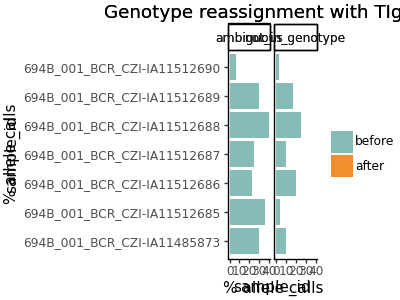

Writing out to individual folders : 100%|██████████| 7/7 [00:37<00:00,  5.43s/it]


In [23]:
for k, v in donor_dic_BCR.items():
    print(k, '\n', v)#, '\n', [x+'.cellranger.all' for x in v], '\n')
    ddl.pp.reassign_alleles(v, combined_folder=k, filename_prefix=[x+'.cellranger.all' for x in v], save_plot=True)

### Step 4: Assigning constant region calls

694B_001_BCR_CZI-IA11485873


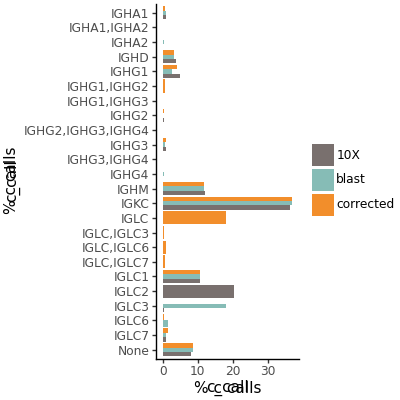

/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/lib/python3.14/site-packages/dandelion/preprocessing/_preprocessing.py:5787: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


694B_001_BCR_CZI-IA11512685


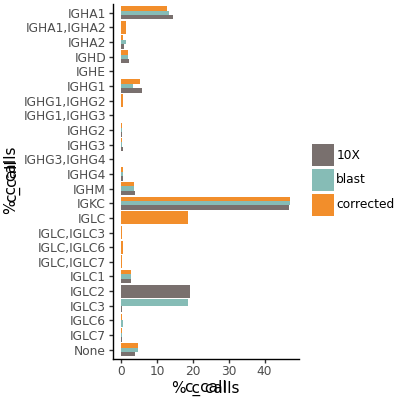

/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/lib/python3.14/site-packages/dandelion/preprocessing/_preprocessing.py:5787: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


694B_001_BCR_CZI-IA11512686


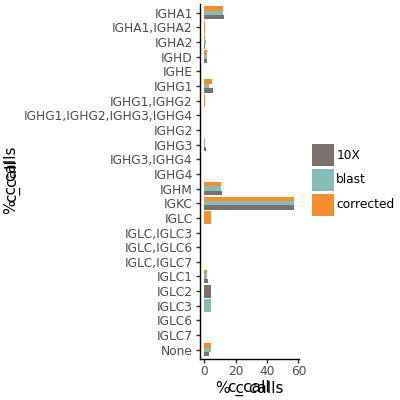

/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/lib/python3.14/site-packages/dandelion/preprocessing/_preprocessing.py:5787: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


694B_001_BCR_CZI-IA11512687


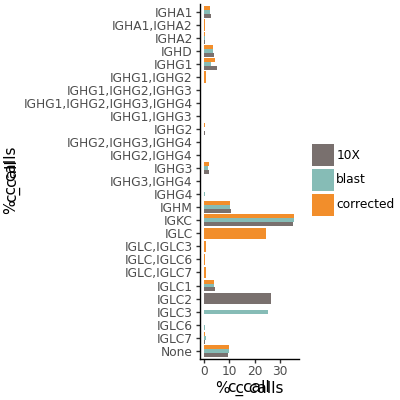

/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/lib/python3.14/site-packages/dandelion/preprocessing/_preprocessing.py:5787: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


694B_001_BCR_CZI-IA11512688


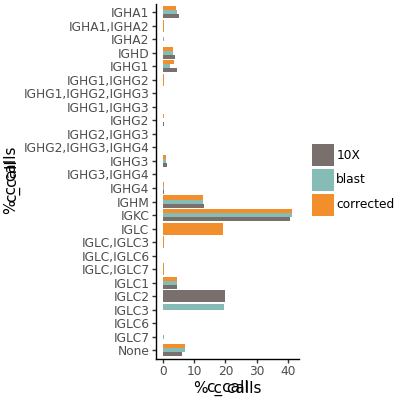

/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/lib/python3.14/site-packages/dandelion/preprocessing/_preprocessing.py:5787: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


694B_001_BCR_CZI-IA11512689


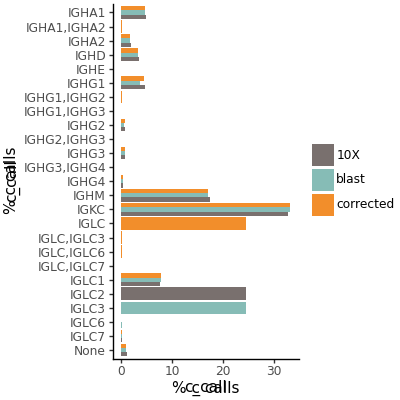

694B_001_BCR_CZI-IA11512690


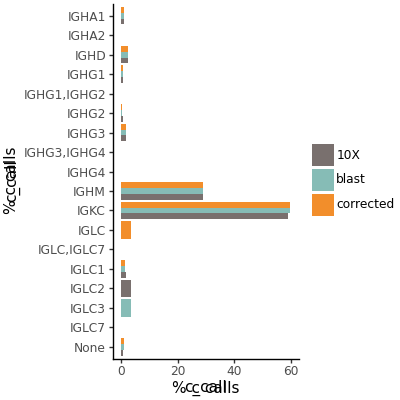

/mnt/nfs/home/anamaceiras/miniforge3/envs/ddl/lib/python3.14/site-packages/dandelion/preprocessing/_preprocessing.py:5787: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [24]:
for sample in BCR_samples:
    print(sample)
    ddl.pp.assign_isotypes(sample, filename_prefix = sample+'.cellranger.all', save_plot=True)

### Step 5: Quantify mutations

In [26]:
# quantify mutations
from tqdm import tqdm
for s in tqdm(BCR_samples, desc = 'Basic mutational load analysis '):
    filePath = s+'/dandelion/'+s+'.cellranger.all_contig_dandelion.tsv'
    ddl.pp.quantify_mutations(filePath)
    #ddl.pp.quantify_mutations(filePath, split_locus = True)
    ddl.pp.quantify_mutations(filePath, combine = False)

Basic mutational load analysis : 100%|██████████| 7/7 [15:37<00:00, 133.87s/it]


### Concatenate BCR reannotated data

In [31]:
bcr_files = []
for sample in BCR_samples:
    file_location = sample +'/dandelion/'+sample+'.cellranger.all_contig_dandelion.tsv'
    #print(file_location)
    bcr_files.append(pd.read_csv(file_location, sep = '\t'))

In [36]:
bcr = pd.concat(bcr_files)
bcr.reset_index(inplace = True, drop = True)

In [37]:
bcr.to_csv('/mnt/nfs/home/'+personal_folder+'/BCR_TCR/TCR_BCR_data/BCR_concatenated_ddl.csv')